In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import warnings

warnings.filterwarnings("ignore")

from sklearn.ensemble import RandomForestClassifier, RandomForestRegressor
from sklearn.linear_model import LogisticRegressionCV, LassoCV
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split, RandomizedSearchCV, GridSearchCV
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import f1_score, classification_report

from utils.data_loader import load_data

# Loading data

In [2]:
final_clean_strained = load_data(db_level=0)

In [3]:
peak_curvs = final_clean_strained["PeakI Curvature"].apply(pd.Series)
peak_curvs.columns = [
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
]
trough_curvs = final_clean_strained["TroughI Curvature"].apply(pd.Series)
trough_curvs.columns = [
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
final_clean_strained = pd.concat(
    [final_clean_strained, peak_curvs, trough_curvs], axis=1
)

In [4]:
# new_cols_df = pd.DataFrame(
#     final_clean_strained["Waveform"].values.tolist(), index=final_clean_strained.index
# )
# final_clean_strained = pd.concat([final_clean_strained, new_cols_df], axis=1)

In [5]:
new_cols_df = pd.DataFrame(
    [x.reset_index(drop=True) for x in final_clean_strained["WaveI"].values.tolist()],
    index=final_clean_strained.index,
)
final_clean_strained = pd.concat([final_clean_strained, new_cols_df], axis=1)

In [6]:
def split_by_mouse(
    data,
    split_on="Subject",
    stratify_on="Group",
    test_size=0.2,
    val_size=0.18,
    random_state=22,
    return_idx=False,
):
    mice = data[[split_on, stratify_on]].drop_duplicates().set_index(split_on)

    train, test = train_test_split(
        mice.index,
        test_size=test_size,
        shuffle=True,
        stratify=mice[stratify_on],
        random_state=random_state,
    )

    train_indices = data[split_on].isin(train)
    test_indices = data[split_on].isin(test)

    train2, val = train_test_split(
        train,
        test_size=val_size,
        shuffle=True,
        stratify=mice.loc[train]["Group"],
        random_state=random_state,
    )

    train2_indices = data[split_on].isin(train2)
    val_indices = data[split_on].isin(val)

    data["DataGroup"] = ""
    data.loc[train2_indices, "DataGroup"] = "Train"
    data.loc[val_indices, "DataGroup"] = "Validate"
    data.loc[test_indices, "DataGroup"] = "Test"
    if return_idx:
        return data, train_indices, train2_indices, val_indices, test_indices
    return data

# Train test split

In [7]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import (
    OneHotEncoder,
    StandardScaler,
    FunctionTransformer,
    MinMaxScaler,
)


def RF_data_prep(
    data,
    num_features,
    cat_features,
    log_features,
    minmax_features,
    target="SynapsesPerIHC",
):
    X = data[num_features + cat_features + log_features + minmax_features]
    y = data[target]

    X_train, X_test, y_train, y_test = (
        X[data.DataGroup != "Test"],
        X[data.DataGroup == "Test"],
        y[data.DataGroup != "Test"],
        y[data.DataGroup == "Test"],
    )

    log_scale_pipeline = Pipeline(
        [
            ("log_transform", FunctionTransformer(np.log1p, validate=True)),
            ("scaler", StandardScaler()),
        ]
    )

    preprocessor = ColumnTransformer(
        transformers=[
            ("num", StandardScaler(), num_features),
            ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
            ("log_transform", log_scale_pipeline, log_features),
            ("minmax_scale", MinMaxScaler(), minmax_features),
        ]
    )

    return X_train, X_test, y_train, y_test, preprocessor

In [8]:
final_clean_strained = split_by_mouse(final_clean_strained)
num_features = ["Amplitude", "Slope", "Distance", "Level(dB)"] + [x for x in range(30)]
cat_features = ["vx", "Strain (binary)"]
log_features = [
    "Frequency(kHz)",
    "Total Variance",
    "PeakI Left Curvature",
    "PeakI Overall Curvature",
    "PeakI Right Curvature",
    "TroughI Left Curvature",
    "TroughI Overall Curvature",
    "TroughI Right Curvature",
]
minmax_features = ["Noise", "Time (hrs)"]
X_train, X_test, y_train, y_test, preprocessor = RF_data_prep(
    final_clean_strained, num_features, cat_features, log_features, minmax_features
)

In [9]:
final_clean_strained

,Subject,Frequency(kHz),Level(dB),Amplitude,vx,SynapsesPerIHC,IHCs,OrphansPerIHC,Waveform,WaveI,...,21,22,23,24,25,26,27,28,29,DataGroup
0,WPZ145,45.2,70.0,0.065036,v1,8.750000,8.8,1.136364,0 -0.112169 1 -0.113246 2 -0.12227...,24 0.085347 25 0.052718 26 0.054619 2...,...,-0.097629,-0.077449,-0.064588,-0.063479,-0.062339,-0.077608,-0.070575,-0.063479,-0.066267,Test
0,WPZ145,45.2,70.0,0.065036,v2,10.888889,9,1.222222,0 -0.112169 1 -0.113246 2 -0.12227...,24 0.085347 25 0.052718 26 0.054619 2...,...,-0.097629,-0.077449,-0.064588,-0.063479,-0.062339,-0.077608,-0.070575,-0.063479,-0.066267,Test
1,WPZ145,45.2,75.0,0.034276,v1,8.750000,8.8,1.136364,0 -0.111887 1 -0.099311 2 -0.07184...,31 -0.177462 32 -0.163745 33 -0.166343 3...,...,-0.139004,-0.154083,-0.154875,-0.165266,-0.150662,-0.171728,-0.184970,-0.165614,-0.131718,Test
1,WPZ145,45.2,75.0,0.034276,v2,10.888889,9,1.222222,0 -0.111887 1 -0.099311 2 -0.07184...,31 -0.177462 32 -0.163745 33 -0.166343 3...,...,-0.139004,-0.154083,-0.154875,-0.165266,-0.150662,-0.171728,-0.184970,-0.165614,-0.131718,Test
2,WPZ145,45.2,80.0,0.153990,v1,8.750000,8.8,1.136364,0 -0.021953 1 -0.030063 2 -0.01473...,44 0.052491 45 0.061552 46 0.070517 4...,...,-0.029208,-0.019894,-0.015966,-0.003390,0.009028,0.012988,0.035163,0.052650,0.047898,Test
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7328,WPZ101,32.0,60.0,1.635883,v2,15.463918,9.7,0.000000,0 -0.048551 1 -0.010029 2 -0.02498...,23 0.206272 24 0.204751 25 0.213115 2...,...,-0.564912,-0.489137,-0.464681,-0.403985,-0.246605,0.044711,0.371001,0.695643,0.898386,Train
7329,WPZ101,32.0,70.0,1.771467,v1,16.923077,9.1,0.000000,0 -0.027782 1 -0.022587 2 -0.06326...,22 -0.028416 23 -0.037919 24 0.001109 2...,...,-0.746886,-0.678714,-0.618905,-0.494978,-0.270440,0.013147,0.352614,0.554597,0.619982,Train
7329,WPZ101,32.0,70.0,1.771467,v2,15.463918,9.7,0.000000,0 -0.027782 1 -0.022587 2 -0.06326...,22 -0.028416 23 -0.037919 24 0.001109 2...,...,-0.746886,-0.678714,-0.618905,-0.494978,-0.270440,0.013147,0.352614,0.554597,0.619982,Train
7330,WPZ101,32.0,80.0,1.879935,v1,16.923077,9.1,0.000000,0 -0.036950 1 -0.055197 2 -0.07344...,21 0.052257 22 0.112573 23 0.155149 2...,...,-0.651515,-0.613500,-0.645432,-0.552171,-0.380853,-0.108163,0.167821,0.333056,0.400215,Train


In [11]:
cols = [
    "Amplitude",
    "Slope",
    "Distance",
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]

reformatted = []

for col in cols:
    df = (
        final_clean_strained.pivot_table(
            index=["Subject", "Frequency"], columns="Level", values=col
        )
        .rename_axis(columns="Level_dB")
        .add_prefix(f"{col}_")
    )
    reformatted.append(df)
reformatted = pd.concat(reformatted, axis=1)

# Add Noise column
noise = final_clean_strained.groupby(["Subject", "Frequency"])["Noise"].mean()
synapses = final_clean_strained.groupby(["Subject", "Frequency"])[
    "SynapsesPerIHC"
].mean()
groups = final_clean_strained.groupby(["Subject", "Frequency"])[
    ["DataGroup", "Strain_b"]
].first()

# Combine
reformatted = reformatted.join(noise).join(synapses).join(groups)

# fill NaNs with interpolated/extrapolated values:
for col in cols:
    amp_cols = [c for c in reformatted.columns if str(c).startswith(col)]
    reformatted[amp_cols] = reformatted[amp_cols].interpolate(
        axis=1, limit_direction="both"
    )

for x in range(30):
    x_col = final_clean_strained.groupby(["Subject", "Frequency"])[x].mean()
    reformatted = reformatted.join(x_col)

reformatted.reset_index(inplace=True)
reformatted.head(10)

,Subject,Frequency,Amplitude_10.0,Amplitude_15.0,Amplitude_20.0,Amplitude_25.0,Amplitude_30.0,Amplitude_35.0,Amplitude_40.0,Amplitude_45.0,...,20,21,22,23,24,25,26,27,28,29
0,WPZ100,8.0,0.077961,0.077961,0.029777,0.090885,0.137358,0.296385,0.381854,0.519497,...,-0.123056,-0.135188,-0.141084,-0.134216,-0.115671,-0.092419,-0.054389,0.006551,0.072566,0.147400
1,WPZ100,11.3,0.050718,0.050718,0.000000,0.168245,0.302752,0.392846,0.477460,0.668926,...,-0.215402,-0.232999,-0.232058,-0.205987,-0.174606,-0.119444,-0.044581,0.039177,0.124842,0.225967
2,WPZ100,16.0,0.059556,0.077295,0.047106,0.121329,0.202553,0.426837,0.424367,0.526245,...,-0.109277,-0.153172,-0.185553,-0.217272,-0.244415,-0.231804,-0.204756,-0.165426,-0.104159,-0.039005
3,WPZ100,22.6,0.063072,0.063072,0.060886,0.098964,0.223176,0.255710,0.359520,0.548261,...,-0.142904,-0.178952,-0.207485,-0.224926,-0.230432,-0.214921,-0.171139,-0.118696,-0.046198,0.039017
4,WPZ100,32.0,0.091900,0.091900,0.257800,0.321347,0.333101,0.498574,0.664046,0.841320,...,-0.260280,-0.295982,-0.304144,-0.303926,-0.279407,-0.215085,-0.123189,-0.003057,0.133781,0.260580
5,WPZ100,45.2,0.079988,0.079988,0.064308,0.129407,0.054423,0.130737,0.151740,0.219944,...,-0.032594,-0.051509,-0.058827,-0.058196,-0.040249,-0.001166,0.045828,0.097092,0.152133,0.202254
6,WPZ101,32.0,0.054107,0.087369,0.057180,0.286407,0.411283,0.572701,0.734120,1.078561,...,-0.290990,-0.292119,-0.259974,-0.231292,-0.183657,-0.099262,0.031808,0.175483,0.292231,0.362181
7,WPZ101,45.2,0.043558,0.111223,0.131910,0.057465,0.140146,0.098869,0.097000,0.115595,...,-0.045469,-0.047571,-0.045695,-0.037668,-0.032479,-0.019715,-0.005119,-0.000866,0.001709,0.003390
8,WPZ102,8.0,0.067254,0.180315,0.126208,0.006525,0.139418,0.266449,0.441124,0.574855,...,-0.219720,-0.210406,-0.202786,-0.173282,-0.120517,-0.056416,0.013176,0.098840,0.184767,0.270757
9,WPZ102,11.3,0.195773,0.029398,0.095163,0.233439,0.310324,0.502138,0.693951,0.728227,...,-0.256573,-0.256247,-0.232732,-0.194581,-0.150789,-0.078422,0.000949,0.106793,0.224175,0.323763


In [12]:
reformatted.columns = reformatted.columns.astype(str)
reformatted["target"] = [0 if x else 1 for x in (reformatted["Noise"] == 0)]

# Lasso

In [13]:
num_features = [f"{x}" for x in range(30)]
cat_features = []
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if c.startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["Noise"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [14]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LassoCV(alphas=[1e-3, 1e-2, 1e-1, 1, 10], cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Lasso training set score: {pipeline.score(X_train, y_train)}")
print(f"Lasso test set score: {pipeline.score(X_test, y_test)}")

Lasso training set score: 0.09589946479147593
Lasso test set score: 0.11664185460036536


# Random Forest Regressor

In [15]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 200, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 20, 'rf__max_features': 'log2', 'rf__max_depth': 30}
Best RF score: 0.017, R2 on test set: 0.252


In [16]:
def plot_results(x, y, alpha=0.5, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([0, 1.1], [0, 1.1], "k--", alpha=0.5)
    plt.axis("square")
    plt.xlim(0, 1.1)
    plt.ylim(0, 1.1)
    plt.title(title)
    plt.xlabel("GT Noise")
    plt.ylabel("Predicted Noise")


def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["Noise"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                1,
                0,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        1,
        0,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        1,
        0,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 102 samples, R2: 0.014, RMSE: 0.450
11.3Hz, 103 samples, R2: 0.144, RMSE: 0.417
16.0Hz, 103 samples, R2: 0.202, RMSE: 0.402
22.6Hz, 103 samples, R2: 0.363, RMSE: 0.359
32.0Hz, 105 samples, R2: 0.331, RMSE: 0.368
45.2Hz, 100 samples, R2: 0.190, RMSE: 0.405
All data, 616 samples, R2: 0.252, RMSE: 0.390


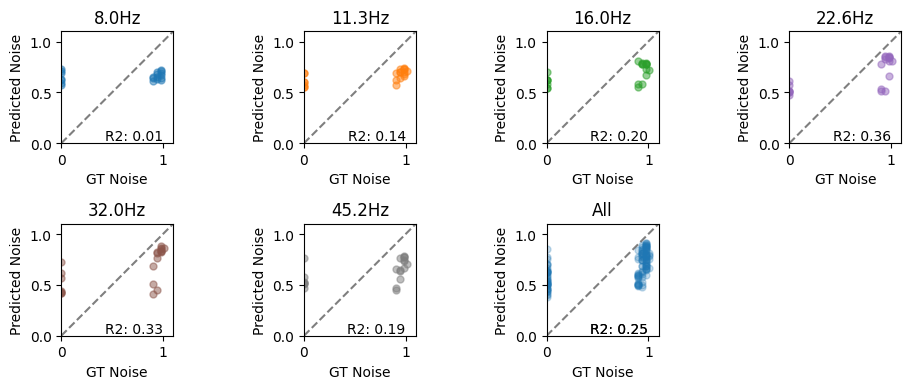

In [17]:
train_plot_result_frequency(reformatted, best_rf_model)

# Logistic Regression

In [19]:
num_features = [f"{x}" for x in range(30)]
cat_features = []
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if str(c).startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if str(c).startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
# y = LabelEncoder().fit_transform(reformatted["Noise"])
y = reformatted["target"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [20]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.7576374745417516
Logistic regression test set accuracy: 0.704


# Random Forest

In [21]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 25, 'rf__min_samples_split': 5, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.3, 'rf__max_depth': 40}
Best RF score: 0.705, R2 on test set: 0.752


In [22]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["target"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            f1 = f1_score(y_test1, preds)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}, F1: {f1:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    f1 = f1_score(y_test, preds)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}, F1: {f1:.3f}")
    print(classification_report(y_test, preds))

In [23]:
train_plot_result_frequency(reformatted, best_rf_model)

8.0Hz, 102 samples, Acc: 0.600, F1: 0.750
              precision    recall  f1-score   support

           0       0.00      0.00      0.00         7
           1       0.63      0.92      0.75        13

    accuracy                           0.60        20
   macro avg       0.32      0.46      0.38        20
weighted avg       0.41      0.60      0.49        20

11.3Hz, 103 samples, Acc: 0.714, F1: 0.824
              precision    recall  f1-score   support

           0       1.00      0.14      0.25         7
           1       0.70      1.00      0.82        14

    accuracy                           0.71        21
   macro avg       0.85      0.57      0.54        21
weighted avg       0.80      0.71      0.63        21

16.0Hz, 103 samples, Acc: 0.667, F1: 0.788
              precision    recall  f1-score   support

           0       0.50      0.14      0.22         7
           1       0.68      0.93      0.79        14

    accuracy                           0.67        21


In [24]:
num_features = [f"{x}" for x in range(30)]
cat_features = []
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if str(c).startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if str(c).startswith(col)]
    num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = LabelEncoder().fit_transform(reformatted["Noise"])

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [25]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.40325865580448067
Logistic regression test set accuracy: 0.432


In [26]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 150, 'rf__min_samples_split': 30, 'rf__min_samples_leaf': 20, 'rf__max_features': 'sqrt', 'rf__max_depth': 5}
Best RF score: 0.328, R2 on test set: 0.400


In [27]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = LabelEncoder().fit_transform(data["Noise"])
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}")
    print(classification_report(y_test, preds))

In [28]:
train_plot_result_frequency(reformatted, best_rf_model)

8.0Hz, 102 samples, Acc: 0.350
              precision    recall  f1-score   support

           0       0.35      1.00      0.52         7
           2       0.00      0.00      0.00         3
           4       0.00      0.00      0.00         1
           5       0.00      0.00      0.00         3
           7       0.00      0.00      0.00         4
           8       0.00      0.00      0.00         2

    accuracy                           0.35        20
   macro avg       0.06      0.17      0.09        20
weighted avg       0.12      0.35      0.18        20

11.3Hz, 103 samples, Acc: 0.333
              precision    recall  f1-score   support

           0       0.33      1.00      0.50         7
           1       0.00      0.00      0.00         1
           2       0.00      0.00      0.00         2
           3       0.00      0.00      0.00         1
           4       0.00      0.00      0.00         2
           5       0.00      0.00      0.00         1
           6   

# Predicting Binary Noise Groups (<91dB vs. >= 91dB)

In [ ]:
reformatted["Noise"].value_counts()

Noise
0.00    193
0.98    115
0.94    100
0.90     82
0.94     37
0.98     28
1.01     16
0.98     14
0.94     13
0.90      9
0.90      9
Name: count, dtype: int64

In [29]:
num_features = []
cat_features = ["Strain_b"]
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    cols = [c for c in reformatted.columns if str(c).startswith(col)]
    log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    cols = [c for c in reformatted.columns if str(c).startswith(col)]
    num_features.extend(cols)

reformatted["target_90"] = [0 if x else 1 for x in (reformatted["Noise"] <= 0.9)]
X = reformatted[num_features + cat_features + log_features]
y = reformatted["target_90"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [30]:
pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        ("elasticnet_cv", LogisticRegressionCV(l1_ratios=(0,), cv=5)),
    ]
)
pipeline.fit(X_train, y_train)
print(f"Logistic regression training set accuracy: {pipeline.score(X_train, y_train)}")
print(f"Logistic regression test set accuracy: {pipeline.score(X_test, y_test)}")

Logistic regression training set accuracy: 0.8472505091649695
Logistic regression test set accuracy: 0.672


In [31]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestClassifier(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 10, 'rf__min_samples_leaf': 30, 'rf__max_features': 'log2', 'rf__max_depth': 40}
Best RF score: 0.632, R2 on test set: 0.776


In [32]:
def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["target_90"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            acc = rf_pipeline.score(X_test1, y_test1)
            preds = rf_pipeline.predict(X_test1)
            print(f"{frq}Hz, {len(data)} samples, Acc: {acc:.3f}")
            print(classification_report(y_test1, preds))

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    acc = rf_pipeline.score(X_test, y_test)
    preds = rf_pipeline.predict(X_test)
    print(f"All data, {len(df)} samples, Acc: {acc:.3f}")
    print(classification_report(y_test, preds))

In [33]:
train_plot_result_frequency(reformatted, best_rf_model)

8.0Hz, 102 samples, Acc: 0.500
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.50      1.00      0.67        10

    accuracy                           0.50        20
   macro avg       0.25      0.50      0.33        20
weighted avg       0.25      0.50      0.33        20

11.3Hz, 103 samples, Acc: 0.524
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.52      1.00      0.69        11

    accuracy                           0.52        21
   macro avg       0.26      0.50      0.34        21
weighted avg       0.27      0.52      0.36        21

16.0Hz, 103 samples, Acc: 0.524
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        10
           1       0.52      1.00      0.69        11

    accuracy                           0.52        21
   macro avg       0.26      0.50

In [34]:
X = reformatted[num_features + cat_features + log_features]
rf_pipeline.fit(X_train, y_train)
reformatted["noise_preds"] = rf_pipeline.predict(X)

In [36]:
num_features = [f"{x}" for x in range(30)]
cat_features = ["Strain_b", "noise_preds"]
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if str(c).startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if str(c).startswith(f"{col}_{i}")]
        num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [37]:
rf_params = {
    "rf__n_estimators": [25, 50, 100, 150, 200, 30, 400, 500],
    "rf__max_depth": [5, 10, 20, 30, 40, 50, None],
    "rf__min_samples_leaf": [2, 5, 10, 15, 20, 30],
    "rf__min_samples_split": [2, 5, 10, 15, 20, 30],
    "rf__max_features": ["sqrt", "log2", 0.3, 0.5],
}

rf_pipeline = Pipeline(
    [("preprocessor", preprocessor), ("rf", RandomForestRegressor(random_state=1))]
)

# Use RandomizedSearchCV for efficiency
rf_search = RandomizedSearchCV(
    rf_pipeline,
    rf_params,
    cv=5,
    scoring="r2",
    random_state=1,
    n_jobs=-1,
)
rf_search.fit(X_train, y_train)
print(f"Best RF params: {rf_search.best_params_}")
r2 = rf_search.score(X_test, y_test)
print(f"Best RF score: {rf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = rf_search.best_estimator_

Best RF params: {'rf__n_estimators': 30, 'rf__min_samples_split': 20, 'rf__min_samples_leaf': 2, 'rf__max_features': 0.5, 'rf__max_depth': None}
Best RF score: 0.261, R2 on test set: 0.511


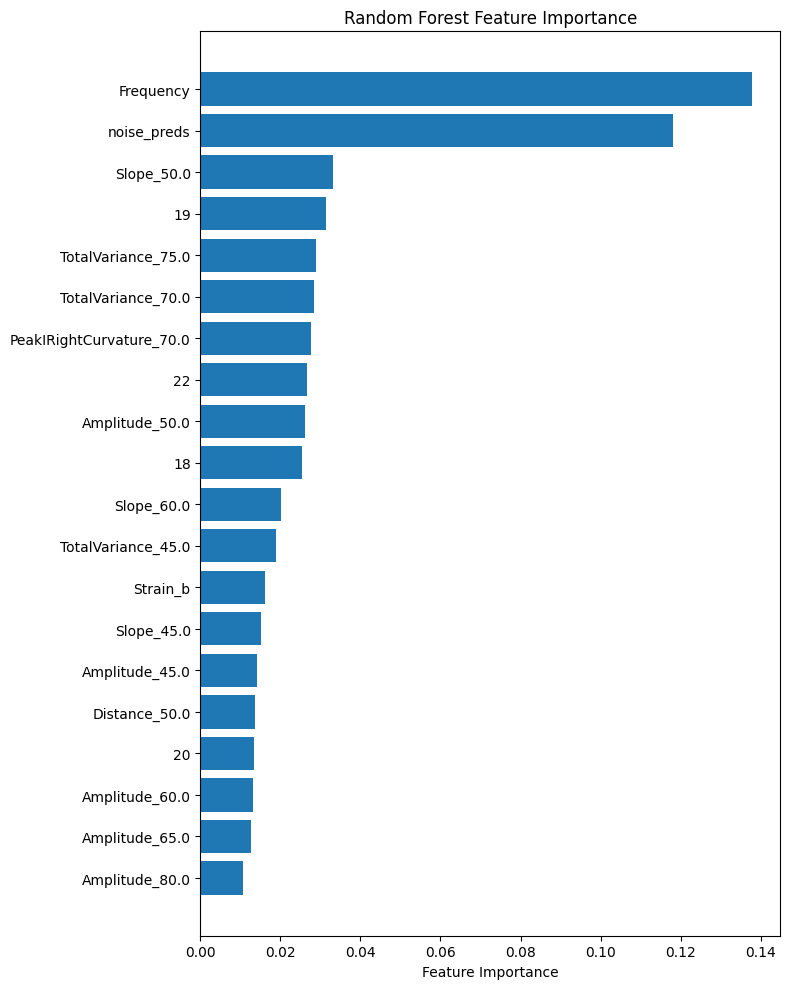

In [38]:
feature_importance = best_rf_model.named_steps["rf"].feature_importances_
feature_names = best_rf_model.feature_names_in_

importance_df = pd.DataFrame(
    {"Feature": feature_names, "Importance": feature_importance}
).sort_values("Importance", ascending=False)

plt.figure(figsize=(8, 10))
plt.barh(range(20), importance_df["Importance"][:20])
plt.yticks(range(20), importance_df["Feature"][:20])
plt.xlabel("Feature Importance")
plt.title("Random Forest Feature Importance")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

In [39]:
def plot_results(x, y, alpha=0.5, markersize=5, title="", color=None):
    if color is None:
        color = np.random.rand(
            3,
        )
        while np.mean(color) > 0.6:
            color = np.random.rand(
                3,
            )
    plt.plot(x, y, "o", alpha=alpha, markersize=markersize, color=color)
    plt.plot([5, 20], [5, 20], "k--", alpha=0.5)
    plt.axis("square")
    plt.xticks(np.arange(5, 21, 5))
    plt.yticks(np.arange(5, 21, 5))
    plt.xlim(5, 20)
    plt.ylim(5, 20)
    plt.title(title)
    plt.xlabel("GT # Synapses")
    plt.ylabel("Predicted # Synapses")


def train_plot_result_frequency(df, rf_pipeline):
    freqs = sorted(X_train["Frequency"].unique())
    plt.figure(figsize=(10, 4))

    color_palette = plt.cm.get_cmap("tab10", len(freqs) + 2)
    # iterate over dB levels:
    for i, frq in zip(range(len(freqs)), freqs):
        features = num_features + cat_features + log_features
        data = df[df["Frequency"] == frq]
        X = data[features]
        y = data["SynapsesPerIHC"]
        X_train1, X_test1, y_train1, y_test1 = (
            X[data.DataGroup != "Test"],
            X[data.DataGroup == "Test"],
            y[data.DataGroup != "Test"],
            y[data.DataGroup == "Test"],
        )
        if len(X_train1) > 0 and len(X_test1) > 0:
            rf_pipeline.fit(X_train1, y_train1)
            r2 = rf_pipeline.score(X_test1, y_test1)
            rmse = np.sqrt(np.mean((y_test1 - rf_pipeline.predict(X_test1)) ** 2))
            print(f"{frq}Hz, {len(data)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
            plt.subplot(2, 4, i + 1)
            plot_results(
                y_test1,
                rf_pipeline.predict(X_test1),
                title=f"{frq}Hz",
                color=color_palette(i),
            )
            # show R2 in lower right corner of plot:
            plt.text(
                19.75,
                5,
                f"R2: {r2:.2f}",
                fontsize=10,
                horizontalalignment="right",
                verticalalignment="bottom",
            )

    # run on all data:
    rf_pipeline.fit(X_train, y_train)
    r2 = rf_pipeline.score(X_test, y_test)
    rmse = np.sqrt(np.mean((y_test - rf_pipeline.predict(X_test)) ** 2))
    print(f"All data, {len(df)} samples, R2: {r2:.3f}, RMSE: {rmse:.3f}")
    plt.subplot(2, 4, 7)
    plot_results(
        y_test,
        rf_pipeline.predict(X_test),
        alpha=0.25,
        title=f"All",
        color=color_palette(-2),
    )
    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    test_set = df[df["DataGroup"] == "Test"]
    test_set["RF predictions"] = rf_pipeline.predict(X_test)

    plt.text(
        19.75,
        5,
        f"R2: {r2:.2f}",
        fontsize=10,
        horizontalalignment="right",
        verticalalignment="bottom",
    )

    plt.tight_layout()
    plt.show()

8.0Hz, 102 samples, R2: 0.193, RMSE: 0.911
11.3Hz, 103 samples, R2: 0.095, RMSE: 1.072
16.0Hz, 103 samples, R2: -0.079, RMSE: 1.316
22.6Hz, 103 samples, R2: 0.534, RMSE: 2.807
32.0Hz, 105 samples, R2: 0.438, RMSE: 3.393
45.2Hz, 100 samples, R2: 0.474, RMSE: 3.330
All data, 616 samples, R2: 0.511, RMSE: 2.460


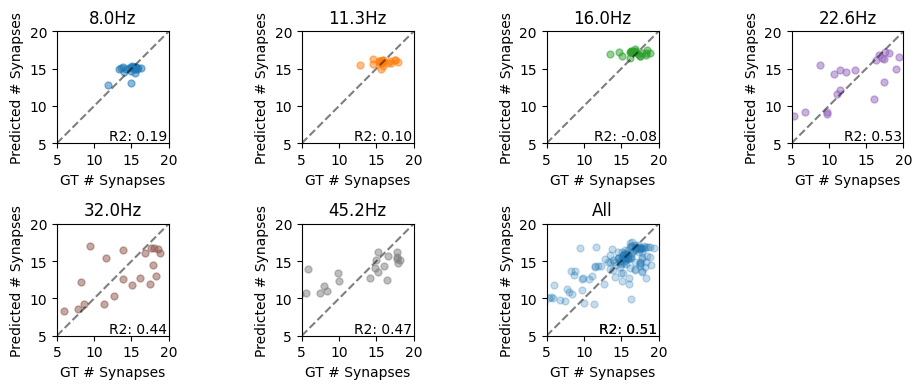

In [40]:
train_plot_result_frequency(reformatted, best_rf_model)

In [41]:
num_features = [f"{x}" for x in range(30)]
cat_features = ["noise_preds"]
log_features = ["Frequency"]
for col in [
    "TotalVariance",
    "PeakILeftCurvature",
    "PeakIOverallCurvature",
    "PeakIRightCurvature",
    "TroughILeftCurvature",
    "TroughIOverallCurvature",
    "TroughIRightCurvature",
]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if str(c).startswith(f"{col}_{i}")]
        log_features.extend(cols)

for col in ["Amplitude", "Slope", "Distance"]:
    for i in [4, 5, 6, 7, 8]:
        cols = [c for c in reformatted.columns if str(c).startswith(f"{col}_{i}")]
        num_features.extend(cols)

X = reformatted[num_features + cat_features + log_features]
y = reformatted["SynapsesPerIHC"]

X_train, X_test, y_train, y_test = (
    X[reformatted.DataGroup != "Test"],
    X[reformatted.DataGroup == "Test"],
    y[reformatted.DataGroup != "Test"],
    y[reformatted.DataGroup == "Test"],
)

log_scale_pipeline = Pipeline(
    [
        ("log_transform", FunctionTransformer(np.log1p, validate=True)),
        ("scaler", StandardScaler()),
    ]
)

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features),
        ("cat", OneHotEncoder(drop="first", sparse_output=False), cat_features),
        ("log_transform", log_scale_pipeline, log_features),
    ]
)

In [42]:
import multiprocessing
import xgboost as xgb

clf_params = {
    "clf__n_estimators": [25, 30, 50, 100, 150, 200, 300, 500],
    "clf__max_depth": [2, 4, 6, 8, 10],
}

clf_pipeline = Pipeline(
    [
        ("preprocessor", preprocessor),
        (
            "clf",
            xgb.XGBRegressor(
                tree_method="hist",
                n_jobs=multiprocessing.cpu_count() // 2,
            ),
        ),
    ]
)

# Use RandomizedSearchCV for efficiency
clf_search = GridSearchCV(
    clf_pipeline,
    clf_params,
    cv=5,
    scoring="r2",
    n_jobs=2,
)
clf_search.fit(X_train, y_train)
print(f"Best RF params: {clf_search.best_params_}")
r2 = clf_search.score(X_test, y_test)
print(f"Best RF score: {clf_search.best_score_:.3f}, R2 on test set: {r2:.3f}")
best_rf_model = clf_search.best_estimator_

Best RF params: {'clf__max_depth': 2, 'clf__n_estimators': 30}
Best RF score: 0.281, R2 on test set: 0.486


8.0Hz, 102 samples, R2: -0.394, RMSE: 1.197
11.3Hz, 103 samples, R2: -0.087, RMSE: 1.175
16.0Hz, 103 samples, R2: -0.243, RMSE: 1.413
22.6Hz, 103 samples, R2: 0.461, RMSE: 3.021
32.0Hz, 105 samples, R2: 0.369, RMSE: 3.597
45.2Hz, 100 samples, R2: 0.562, RMSE: 3.039
All data, 616 samples, R2: 0.486, RMSE: 2.524


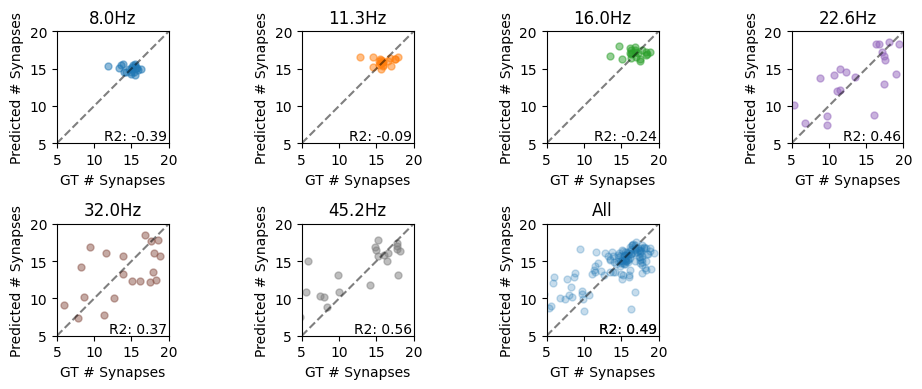

In [43]:
train_plot_result_frequency(reformatted, best_rf_model)